<a href="https://colab.research.google.com/github/donw385/Big-Data-Bowl/blob/master/NFL_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [0]:
#imports 

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import altair as alt
import itertools
import re
import plotly.plotly as py
import plotly.tools as tls
from vega_datasets import data
pd.options.display.max_columns = 500



In [0]:
#read data

games = pd.read_csv('https://raw.githubusercontent.com/donw385/Big-Data-Bowl/master/Data/games.csv')
players = pd.read_csv('https://raw.githubusercontent.com/donw385/Big-Data-Bowl/master/Data/players.csv')
plays = pd.read_csv('https://raw.githubusercontent.com/donw385/Big-Data-Bowl/master/Data/plays.csv')

In [3]:
games.shape, players.shape, plays.shape

((91, 21), (1713, 10), (14193, 27))

In [4]:
games.columns

Index(['season', 'week', 'gameDate', 'gameId', 'gameTimeEastern', 'HomeScore',
       'VisitorScore', 'homeTeamAbbr', 'visitorTeamAbbr', 'homeDisplayName',
       'visitorDisplayName', 'Stadium', 'Location', 'StadiumType', 'Turf',
       'GameLength', 'GameWeather', 'Temperature', 'Humidity', 'WindSpeed',
       'WindDirection'],
      dtype='object')

In [5]:
players.head()

,nflId,FirstName,LastName,PositionAbbr,EntryYear,DraftRound,DraftNumber,Height,Weight,College
0,79860,John,Stafford,QB,2009,1.0,1.0,"6'03""",220,Georgia
1,71465,Andre,Smith,T,2009,1.0,6.0,"6'04""",325,Alabama
2,80427,Darrius,Heyward-Bey,WR,2009,1.0,7.0,"6'02""",210,Maryland
3,71269,Michael,Crabtree,WR,2009,1.0,10.0,"6'01""",214,Texas Tech
4,71423,Brian,Orakpo,OLB,2009,1.0,13.0,"6'04""",257,Texas


In [0]:
def decimalize_feet(s):
    m = re.match(r'^(\d+)\'(\d+)\"$', s)
    if m:
        return float(m.group(1)) + float(m.group(2)) / 12.
    else:
        return None
  
players['Height'] = players['Height'].apply(lambda x:decimalize_feet(x))


In [7]:
players.head()

,nflId,FirstName,LastName,PositionAbbr,EntryYear,DraftRound,DraftNumber,Height,Weight,College
0,79860,John,Stafford,QB,2009,1.0,1.0,6.250000,220,Georgia
1,71465,Andre,Smith,T,2009,1.0,6.0,6.333333,325,Alabama
2,80427,Darrius,Heyward-Bey,WR,2009,1.0,7.0,6.166667,210,Maryland
3,71269,Michael,Crabtree,WR,2009,1.0,10.0,6.083333,214,Texas Tech
4,71423,Brian,Orakpo,OLB,2009,1.0,13.0,6.333333,257,Texas


In [8]:
players.columns

Index(['nflId', 'FirstName', 'LastName', 'PositionAbbr', 'EntryYear',
       'DraftRound', 'DraftNumber', 'Height', 'Weight', 'College'],
      dtype='object')

In [97]:
players.shape

(1713, 10)

In [0]:
colleges = players['College'].value_counts()
top_20=colleges.head(20)

In [0]:
college_list = top_20.index.values.tolist()


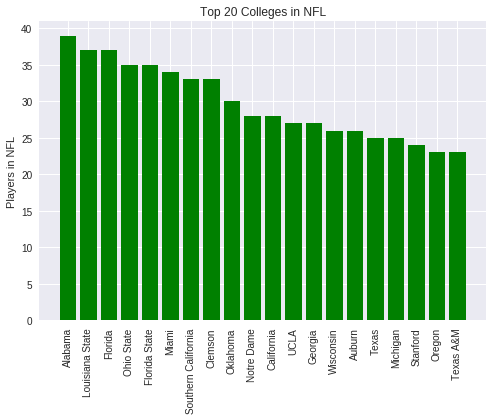

In [117]:
plt.bar(college_list,top_20, label="Example two", color='g')
plt.xticks(rotation='vertical')
plt.ylabel('Players in NFL')

plt.title('Top 20 Colleges in NFL')

plt.show()


In [9]:
position_summary = players.groupby('PositionAbbr').describe()
position_summary.head(25)



DraftNumber                                                       \
                   count        mean        std    min     25%    50%     75%   
PositionAbbr                                                                    
C                   43.0  114.651163  75.048202   15.0   55.50   93.0  189.00   
CB                 131.0   99.992366  72.980766    5.0   30.50   89.0  157.50   
DB                   1.0   24.000000        NaN   24.0   24.00   24.0   24.00   
DE                 103.0   82.737864  66.093214    1.0   31.50   69.0  119.00   
DT                  81.0   98.160494  70.384028    2.0   44.00   88.0  151.00   
FB                  10.0  174.500000  37.936350  108.0  144.00  186.5  204.00   
FS                  56.0  105.303571  74.967610   14.0   38.75   84.0  174.75   
G                   74.0   93.229730  59.259251    2.0   45.75   81.5  133.75   
ILB                 41.0  104.585366  74.413028    7.0   40.00  113.0  154.00   
K                   12.0  183.750000  37.863691  118.0  164.75  176.0  200.75   
LB                   1.0  232.000000        NaN  232.0  232.00  232.0  232.00   
LS                   3.0  175.000000  63.976558  116.0  141.00  166.0  204.50   
MLB                 28.0  102.142857  72.984886    9.0   38.00   87.5  162.00   
NT                  18.0   95.666667  54.785142   27.0   43.75   89.5  123.00   
OLB                 97.0   95.989691  69.079286    1.0   36.00   83.0  153.00   
P                   16.0  174.000000  45.410718   70.0  151.75  183.5  204.00   
QB                  47.0   75.085106  79.718480    1.0    3.00   52.0  135.00   
RB                  85.0  110.835294  64.440975    4.0   57.00  106.0  154.00   
SS                  46.0  100.130435  61.735136    5.0   51.75   99.0  143.50   
T                   80.0   89.025000  78.965138    1.0   20.75   63.0  153.50   
TE                  76.0  106.671053  63.478582    6.0   50.75   99.0  159.25   
WR                 136.0   90.985294  67.120564    3.0   33.75   80.5  141.25   

                    DraftRound                                                \
                max      count      mean       std  min  25%  50%   75%  max   
PositionAbbr                                                                   
C             251.0       43.0  3.744186  2.036489  1.0  2.0  3.0  6.00  7.0   
CB            254.0      131.0  3.381679  2.024686  1.0  1.0  3.0  5.00  7.0   
DB             24.0        1.0  1.000000       NaN  1.0  1.0  1.0  1.00  1.0   
DE            239.0      103.0  2.980583  1.782159  1.0  1.5  3.0  4.00  7.0   
DT            249.0       81.0  3.370370  1.900292  1.0  2.0  3.0  5.00  7.0   
FB            215.0       10.0  5.500000  0.971825  4.0  5.0  6.0  6.00  7.0   
FS            245.0       56.0  3.607143  2.086132  1.0  2.0  3.0  6.00  7.0   
G             243.0       74.0  3.243243  1.611694  1.0  2.0  3.0  4.00  7.0   
ILB           250.0       41.0  3.512195  2.013976  1.0  2.0  4.0  5.00  7.0   
K             256.0       12.0  5.833333  0.937437  4.0  5.0  6.0  6.25  7.0   
LB            232.0        1.0  7.000000       NaN  7.0  7.0  7.0  7.00  7.0   
LS            243.0        3.0  5.333333  1.527525  4.0  4.5  5.0  6.00  7.0   
MLB           251.0       28.0  3.464286  1.914509  1.0  2.0  3.0  5.00  7.0   
NT            220.0       18.0  3.222222  1.592466  1.0  2.0  3.0  4.00  7.0   
OLB           233.0       97.0  3.319588  1.934050  1.0  2.0  3.0  5.00  7.0   
P             235.0       16.0  5.500000  1.211060  3.0  5.0  6.0  6.00  7.0   
QB            250.0       47.0  2.787234  2.042336  1.0  1.0  2.0  4.00  7.0   
RB            252.0       85.0  3.717647  1.756700  1.0  2.0  4.0  5.00  7.0   
SS            244.0       46.0  3.456522  1.656053  1.0  2.0  3.5  5.00  7.0   
T             255.0       80.0  3.100000  2.138259  1.0  1.0  2.0  5.00  7.0   
TE            246.0       76.0  3.618421  1.781139  1.0  2.0  3.0  5.00  7.0   
WR            245.0      136.0  3.176471  1.861431  1.0  2.0  3.0  

In [0]:
height_and_weight = position_summary.loc[:, list(itertools.product(['Height','Weight'], ['50%']))]


In [0]:
height_and_weight=height_and_weight.reset_index()

In [0]:
height_and_weight['Height'] = height_and_weight['Height'].round(2)
height_and_weight['Weight'] = height_and_weight['Weight'].round(2)

In [70]:
height_and_weight

,PositionAbbr,Height,Weight
,,50%,50%
0,C,6.33,305.0
1,CB,6.00,195.0
2,DB,6.00,195.0
3,DE,6.33,272.5
4,DT,6.25,305.0
5,FB,6.08,240.0
6,FS,6.00,205.0
7,G,6.33,314.0
8,ILB,6.08,237.0


In [0]:
position_list = height_and_weight['PositionAbbr'].tolist()
position_list

In [0]:
height_list = height_and_weight['Height'].values.tolist()


In [0]:
weight_list = height_and_weight['Weight'].values.tolist()
 

In [102]:
height = height_and_weight.Height
weight = height_and_weight.Weight

x = height_list
y = weight_list
types= position_list

xrange = [5, 7]
yrange = [150, 350]


source = pd.DataFrame({
    'x': height_list,
    'y': weight_list,
    'label': position_list
})

bars = alt.Chart(source).mark_point().encode(
    x=alt.X('x', axis=alt.Axis(title='Height in inches',grid=True)),
    y=alt.Y('y', axis=alt.Axis(title='Weight in pounds',grid=True))
)

text = bars.mark_text(
    align='left',
    baseline='middle',
    dx=7
).encode(
    text='label'
).interactive()


bars + text



LayerChart({
  layer: [Chart({
    data:    label       x        y
    0      C  [6.33]  [305.0]
    1     CB   [6.0]  [195.0]
    2     DB   [6.0]  [195.0]
    3     DE  [6.33]  [272.5]
    4     DT  [6.25]  [305.0]
    5     FB  [6.08]  [240.0]
    6     FS   [6.0]  [205.0]
    7      G  [6.33]  [314.0]
    8    ILB  [6.08]  [237.0]
    9      K   [6.0]  [197.5]
    10    LB  [6.17]  [228.5]
    11    LS  [6.21]  [243.5]
    12   MLB  [6.08]  [238.5]
    13    NT  [6.25]  [314.0]
    14   OLB  [6.25]  [245.0]
    15     P  [6.17]  [210.0]
    16    QB  [6.33]  [223.5]
    17    RB  [5.92]  [215.0]
    18    SS   [6.0]  [208.0]
    19     T   [6.5]  [315.0]
    20    TE  [6.42]  [255.0]
    21    WR  [6.08]  [202.0],
    encoding: EncodingWithFacet({
      x: X({
        axis: Axis({
          grid: True,
          title: 'Height in inches'
        }),
        shorthand: 'x'
      }),
      y: Y({
        axis: Axis({
          grid: True,
          title: 'Weight in pounds'
        }),
        shorthand: 'y'
      })
    }),
    mark: 'point'
  }), Chart({
    data:    label       x        y
    0      C  [6.33]  [305.0]
    1     CB   [6.0]  [195.0]
    2     DB   [6.0]  [195.0]
    3     DE  [6.33]  [272.5]
    4     DT  [6.25]  [305.0]
    5     FB  [6.08]  [240.0]
    6     FS   [6.0]  [205.0]
    7      G  [6.33]  [314.0]
    8    ILB  [6.08]  [237.0]
    9      K   [6.0]  [197.5]
    10    LB  [6.17]  [228.5]
    11    LS  [6.21]  [243.5]
    12   MLB  [6.08]  [238.5]
    13    NT  [6.25]  [314.0]
    14   OLB  [6.25]  [245.0]
    15     P  [6.17]  [210.0]
    16    QB  [6.33]  [223.5]
    17    RB  [5.92]  [215.0]
    18    SS   [6.0]  [208.0]
    19     T   [6.5]  [315.0]
    20    TE  [6.42]  [255.0]
    21    WR  [6.08]  [202.0],
    encoding: EncodingWithFacet({
      text: Text({
        shorthand: 'label'
      }),
      x: X({
        axis: Axis({
          grid: True,
          title: 'Height in inches'
        }),
        shorthand: 'x'
      }),
      y: Y({
        axis: Axis({
          grid: True,
          title: 'Weight in pounds'
        }),
        shorthand: 'y'
      })
    }),
    mark: MarkDef({
      align: 'left',
      baseline: 'middle',
      dx: 7,
      type: 'text'
    }),
    selection: SelectionMapping({
      selector015: SelectionDef({
        bind: 'scales',
        encodings: ['x', 'y'],
        type: 'interval'
      })
    })
  })]
})

In [0]:
position_summary.head()

In [0]:
position_table.corr()

In [0]:
plays.columns

In [0]:
plays.corr()

In [0]:
crosstab = pd.crosstab(plays['offenseFormation'],plays['defendersInTheBox'])

crosstab

In [0]:
f, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(crosstab, annot=True, fmt="d", linewidths=.5, ax=ax);